<a href="https://colab.research.google.com/github/jellYTM/tokuronXIV2026/blob/main/sir.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIR model
感染症の流行過程を記述するモデル  

$$
\begin{cases}
\frac{dS(t)}{dt} = -\beta S(t) I(t)\\
\frac{dI(t)}{dt} = \beta S(t) I(t) - \gamma I(t)\\
\frac{dR(t)}{dt} = \gamma I(t)
\end{cases}
$$

## 変数  

$S(t)$: 感受性保持者（susceptible）  
$I(t)$: 感染性保持者（Infectious）  
$R(t)$: 回復者（Recovered） or 隔離者（Removed）  

## パラメータ

$\beta$: 感染性（感染力）  
$\gamma$: 回復率  
$T(0)$: 感受性保持者の初期値（最初の時刻の時の値）

## 以下参考

### 基本再生産数

$R_0$: 基本再生産数
$$
R_0=\frac{\beta S(0)}{\gamma}
$$
  
$z=\frac{R(\infty)}{S(\infty)+I(\infty)+R(\infty)}$: 最終規模（final size）  
  
### 最終規模方程式（final size equation）  

$R_0$と最終規模の関係
$$
1-z=\exp(-zR_0)
$$
  
$$
R_0=-\frac{\ln(1-z)}{z}
$$

### 接触を減らす
（＝$\beta$を小さくする）

時刻$t$について  
$t<t_\varepsilon$のとき、$\varepsilon = 0$  
$t≥t_\varepsilon$のとき、$0 < \varepsilon <1$  

$$
\begin{cases}
\frac{dS(t)}{dt} = -(1-\varepsilon)\beta S(t) I(t)\\
\frac{dI(t)}{dt} = (1-\varepsilon)\beta S(t) I(t) - \gamma I(t)\\
\frac{dR(t)}{dt} = \gamma I(t)
\end{cases}
$$

---

## 生成AIでコードを生成して、自分でコードを実行してみましょう。

### 生成AIの利用

Microsoft 365 Copilotが利用可能です。
- [https://m365.cloud.microsoft](https://m365.cloud.microsoft)

そのほか、個人で利用しているサービスでも構いませんが、自己責任となります。
- [OpenAI ChatGPT](https://chatgpt.com)
- [Google Gemini](https://gemini.google.com)
- [Anthropic Claude](https://claude.ai)

### 目標

新型コロナウイルス感染症流行時の、いわゆる第５波（2021年7月1日から9月30日ごろ）における、愛知県のCOVID-19の新規感染者数のデータから、SIRモデルのパラメータを推定し、流行に関する考察を行う。

#### 小目標

- チャットベースの生成AIサービスを利用する。
- Google ColabratoryでPythonのコードを実行する。
- 公開データから愛知県におけるCOVID-19の新規感染者数のデータを読み込む。
- 読み込んだデータの内容を確認する。
- 新規感染者数のデータをプロットして可視化する。
- 微分方程式で記述された数理モデル（SIRモデル）の数値計算を行う。
- 数理モデルの計算結果と、データを重ねてプロットする。
- データに合う数理モデルのパラメータを探す。
  - パラメータ探索を自動化する。（希望者のみ）
- パラメータの値から、数理モデルの仮定を加味して、流行時の感染者数の変化を考察する。


#### ポイント

- AIの出力でわからないことがあれば、そのまま解説をお願いしましょう。
- エラーが出た場合は、全文をコピーして、チャットサービスに貼り付けましょう。
- Colab内のGeminiに頼るのもいいでしょう。
- 途中で修正により整合性が取れなくなったら、それまでで動いているコードを貼り付けるといいでしょう。
  - 初めからやり直すのも一つの選択肢。

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
import datetime

## 公開データから愛知県におけるCOVID-19の新規感染者数のデータを読み込む。

**プロンプトの例**

> Google ColabratoryでPythonを用いて、SIRモデルとCOVID-19の新規感染者数のデータフィッティングを行います。まずは、愛知県における新規感染者数の公開データを読み込むコードを書いてください。


In [2]:
url = "https://covid19.mhlw.go.jp/public/opendata/newly_confirmed_cases_daily.csv"
print("データを読み込んでいます...")
data = pd.read_csv(url)

データを読み込んでいます...


## 読み込んだデータの内容を確認する。

> 読み込んだデータの概要を確認するコードを書いてください。

In [3]:
print("\n--- データの概要 ---")
print(data.head())


--- データの概要 ---
        Date  ALL  Hokkaido  Aomori  Iwate  Miyagi  Akita  Yamagata  \
0  2020/1/16    1         0       0      0       0      0         0   
1  2020/1/17    0         0       0      0       0      0         0   
2  2020/1/18    0         0       0      0       0      0         0   
3  2020/1/19    0         0       0      0       0      0         0   
4  2020/1/20    0         0       0      0       0      0         0   

   Fukushima  Ibaraki  ...  Ehime  Kochi  Fukuoka  Saga  Nagasaki  Kumamoto  \
0          0        0  ...      0      0        0     0         0         0   
1          0        0  ...      0      0        0     0         0         0   
2          0        0  ...      0      0        0     0         0         0   
3          0        0  ...      0      0        0     0         0         0   
4          0        0  ...      0      0        0     0         0         0   

   Oita  Miyazaki  Kagoshima  Okinawa  
0     0         0          0        0  
1 

## 新規感染者数のデータをプロットして可視化する。

**プロンプトの例**

> 読み込んだデータの新規感染者数を時系列で可視化するコードを書いてください。

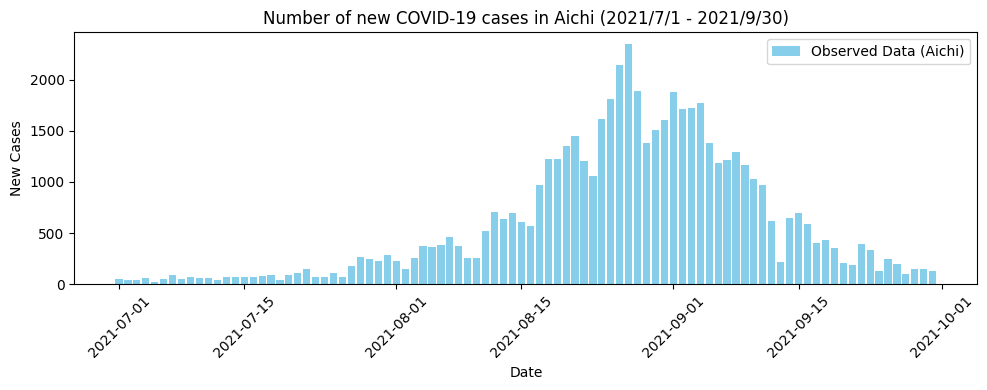

In [4]:
# 日付型に変換
data['Date'] = pd.to_datetime(data['Date'])
# 愛知県のデータのみ抽出
data_aichi = data[['Date', 'Aichi']].copy()

# 対象期間（第5波の例：2021年7月1日〜9月30日）を絞り込み
start_date = datetime.datetime(2021, 7, 1)
end_date = datetime.datetime(2021, 9, 30)
mask = (data_aichi['Date'] >= start_date) & (data_aichi['Date'] <= end_date)
data_target = data_aichi.loc[mask]

# 新規感染者数のプロット
plt.figure(figsize=(10, 4))
plt.bar(data_target['Date'], data_target['Aichi'], color='skyblue', label='Observed Data (Aichi)')
plt.title('Number of new COVID-19 cases in Aichi (2021/7/1 - 2021/9/30)')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## 微分方程式で記述された数理モデル（SIRモデル）の数値計算を行う。

**プロンプトの例**

> 微分方程式
$$
\begin{cases}
\frac{dS(t)}{dt} = -\beta S(t) I(t)\\
\frac{dI(t)}{dt} = \beta S(t) I(t) - \gamma I(t)\\
\frac{dR(t)}{dt} = \gamma I(t)
\end{cases}
$$
をオイラー法で計算するためのコードを書いてください。

In [5]:
# SIRモデルの微分方程式
def sir_model(y, t, beta, gamma):
    S, I, R = y
    dSdt = -beta * S * I
    dIdt = beta * S * I - gamma * I
    dRdt = gamma * I
    return [dSdt, dIdt, dRdt]

# 時間ステップ（日数）
t_days = len(data_target)
t = np.arange(t_days)

# 初期の仮パラメータと初期値
I0 = data_target['Aichi'].iloc[0] # 初日の感染者数を初期値とする
R0 = 0
S0_init = 60000  # ノートブックの仮定値
beta_init = 0.000008
gamma_init = 0.1

# 微分方程式を解く
y0_init = [S0_init, I0, R0]
result_init = odeint(sir_model, y0_init, t, args=(beta_init, gamma_init))
S_init, I_init, R_init = result_init.T

# 新規感染者数は β * S * I で計算
new_cases_init = beta_init * S_init * I_init

## 数理モデルの計算結果と、データを重ねてプロットする。

**プロンプトの例**

> SIRモデルで計算される新規感染者数と、読み込んだ愛知県の日毎の新規感染者数の2021年7月1日から9月30日のデータを重ねてプロットするコードを書いてください。

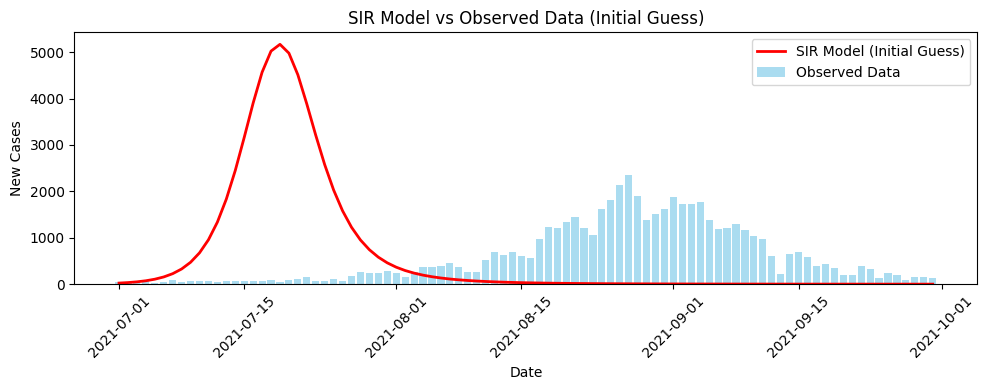

In [6]:
# データと初期モデルの比較プロット
plt.figure(figsize=(10, 4))
plt.bar(data_target['Date'], data_target['Aichi'], color='skyblue', alpha=0.7, label='Observed Data')
plt.plot(data_target['Date'], new_cases_init, color='red', linewidth=2, label='SIR Model (Initial Guess)')
plt.title('SIR Model vs Observed Data (Initial Guess)')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## データに合う数理モデルのパラメータを探す。

**プロンプトの例**

> SIRモデルのパラメータと初期値の値をデータに合うように推定したいので、パラメータの値を変更することで、計算された新規感染者数とデータの2021年7月1日から9月30日の新規感染者数を重ねてプロットするコードを書いてください。

6561通りのパラメータ組み合わせを計算中... (しばらくお待ちください)

計算完了！
--- 抽出されたベストパラメータ ---
β: 0.00000450,  γ: 0.2250,  S(0): 80000.0,  I(0): 10.0
最小二乗誤差 (MSE): 46527.91
基本再生産数 (R0): 1.60


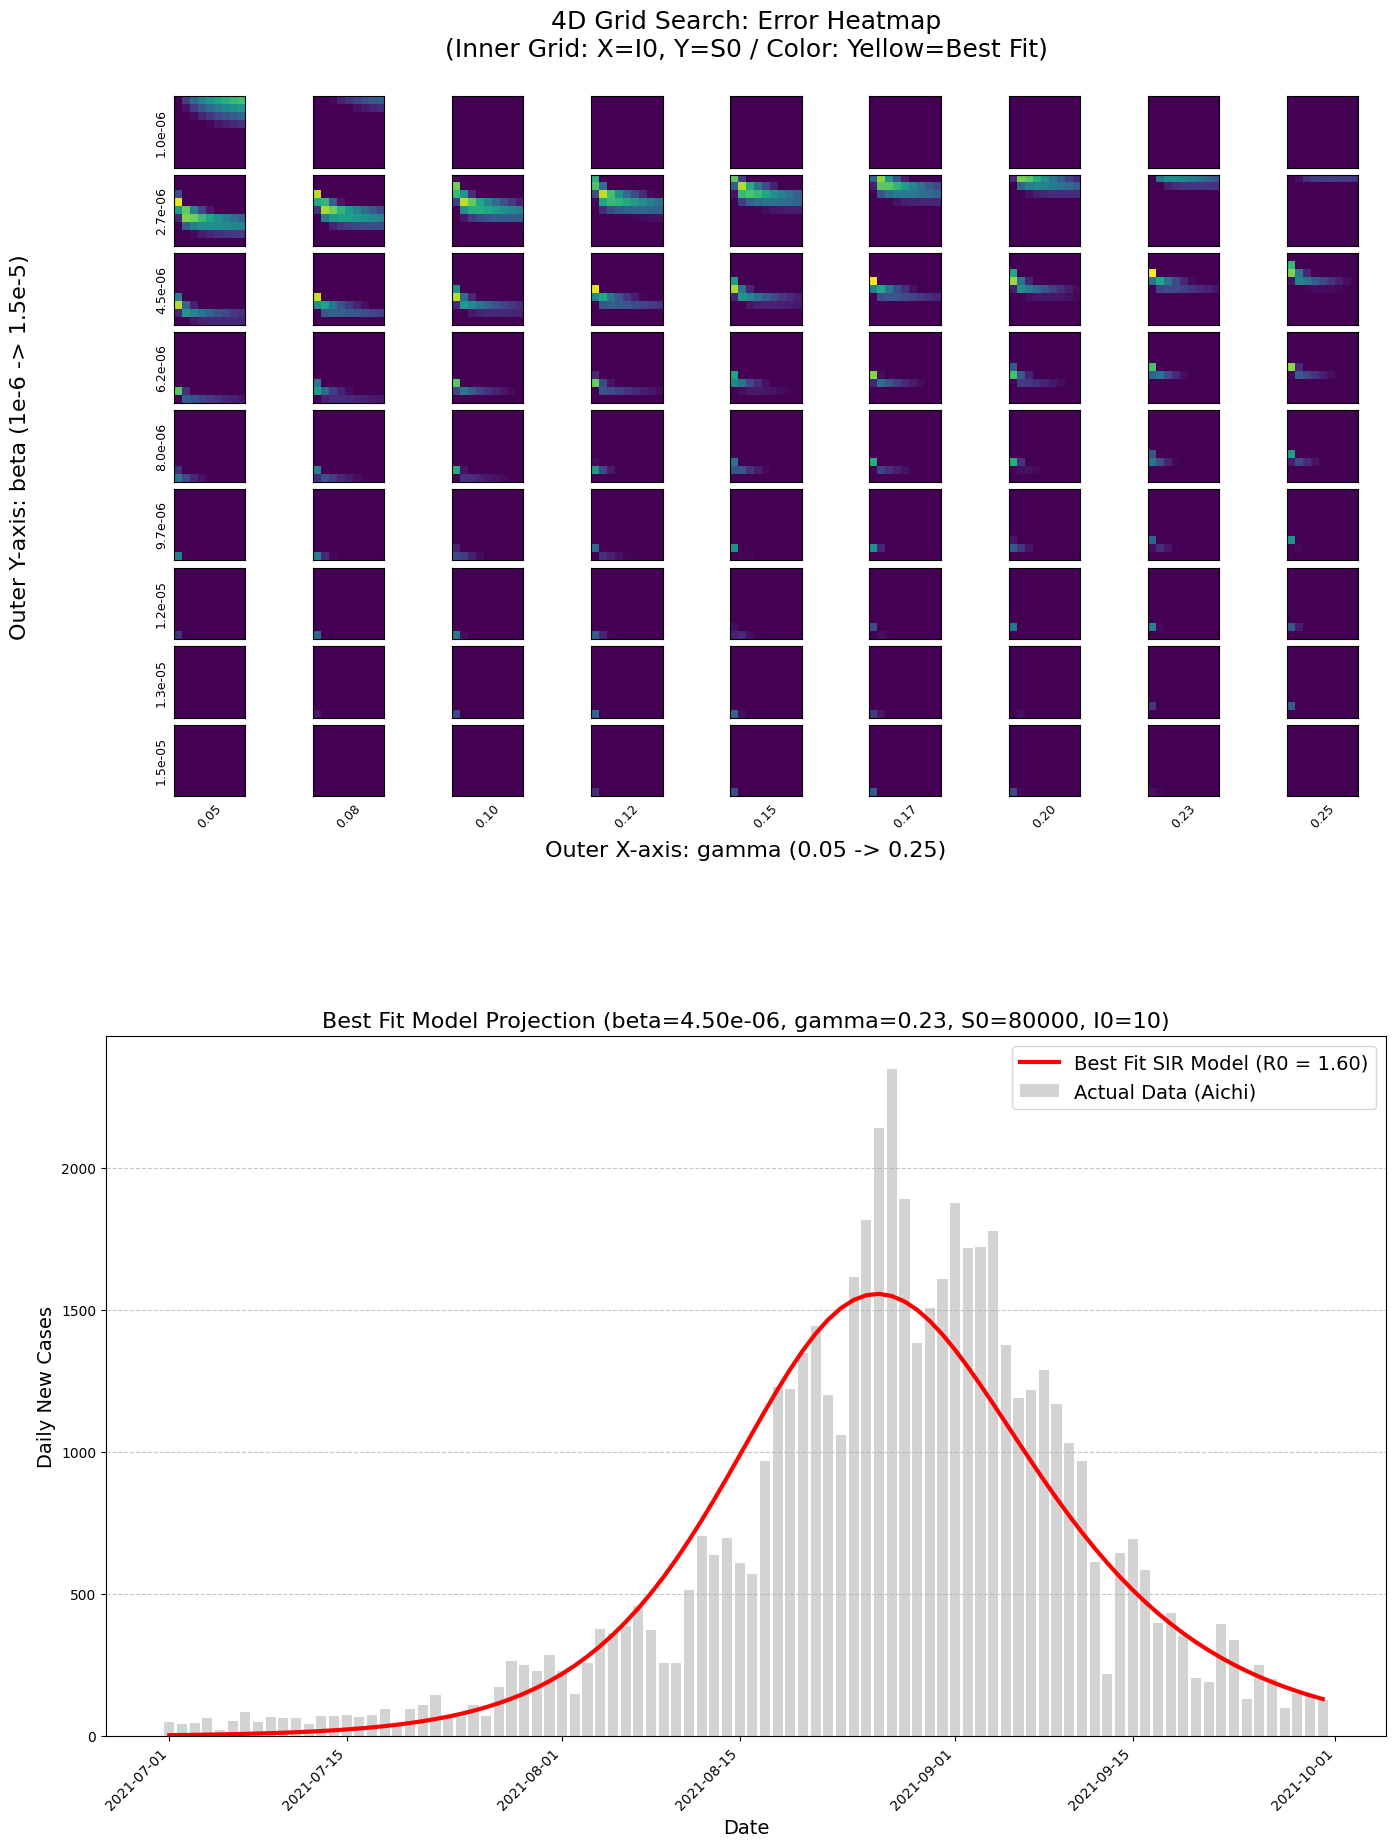

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import odeint
# 1. 探索する4つのパラメータの候補を設定 (9x9x9x9 = 6561通り)
betas = np.linspace(1e-6, 1.5e-5, 9)     # 感染率
gammas = np.linspace(0.05, 0.25, 9)      # 回復率
S0s = np.linspace(20000, 100000, 9)      # 初期感受性人口
I0s = np.linspace(10, 1000, 9)           # 初期感染者数

# 誤差（MSE）を格納する配列
errors = np.zeros((9, 9, 9, 9))

print("6561通りのパラメータ組み合わせを計算中... (しばらくお待ちください)")

# 実データと時間の準備（前のセルで定義した data_target を使用）
t_days = len(data_target)
t = np.arange(t_days)
actual_data = data_target['Aichi'].values

# SIRモデル (高速計算用)
def sir_model_search(y, t, beta, gamma):
    S, I, R = y
    return [-beta * S * I, beta * S * I - gamma * I, gamma * I]

# 4重ループによる全探索の実行
for i, b in enumerate(betas):
    for j, g in enumerate(gammas):
        for k, s0 in enumerate(S0s):
            for l, i0 in enumerate(I0s):
                res = odeint(sir_model_search, [s0, i0, 0], t, args=(b, g))
                new_cases_sim = b * res[:, 0] * res[:, 1]
                # 実データとの平均二乗誤差 (MSE)
                mse = np.mean((new_cases_sim - actual_data)**2)
                errors[i, j, k, l] = mse

# ==========================================
# 2. 結果の自動抽出
# ==========================================
# エラー配列の中で最も値が小さい（＝最も実データに近い）インデックスを取得
min_idx = np.unravel_index(np.argmin(errors), errors.shape)

# ベストなパラメータを配列から自動取得
best_b = betas[min_idx[0]]
best_g = gammas[min_idx[1]]
best_s0 = S0s[min_idx[2]]
best_i0 = I0s[min_idx[3]]
best_mse = errors[min_idx]
best_r0 = (best_b * best_s0) / best_g

print("\n計算完了！")
print(f"--- 抽出されたベストパラメータ ---")
print(f"β: {best_b:.8f},  γ: {best_g:.4f},  S(0): {best_s0:.1f},  I(0): {best_i0:.1f}")
print(f"最小二乗誤差 (MSE): {best_mse:.2f}")
print(f"基本再生産数 (R0): {best_r0:.2f}")

# ==========================================
# 3. プロットの描画（上段：ヒートマップ、下段：近似グラフ）
# ==========================================
fig = plt.figure(figsize=(16, 20)) # 縦長の大きなキャンバスを作成

# --- 上段：4Dヒートマップ ---
outer_grid = gridspec.GridSpec(9, 9, wspace=0.1, hspace=0.1, top=0.9, bottom=0.55)
vmin = np.min(errors)
vmax = np.percentile(errors, 10)

for i in range(9):
    for j in range(9):
        ax = plt.Subplot(fig, outer_grid[i, j])
        ax.imshow(errors[i, j, :, :], vmin=vmin, vmax=vmax, cmap='viridis_r', origin='lower')
        ax.set_xticks([])
        ax.set_yticks([])
        if i == 8:
            ax.set_xlabel(f"{gammas[j]:.2f}", fontsize=9, rotation=45)
        if j == 0:
            ax.set_ylabel(f"{betas[i]:.1e}", fontsize=9)
        fig.add_subplot(ax)

fig.text(0.5, 0.52, 'Outer X-axis: gamma (0.05 -> 0.25)', ha='center', fontsize=16)
fig.text(0.04, 0.725, 'Outer Y-axis: beta (1e-6 -> 1.5e-5)', va='center', rotation='vertical', fontsize=16)
fig.text(0.5, 0.92, '4D Grid Search: Error Heatmap\n(Inner Grid: X=I0, Y=S0 / Color: Yellow=Best Fit)', ha='center', fontsize=18)

# --- 下段：自動抽出されたベストモデルの近似グラフ ---
# 下半分の領域に新しいグラフ枠を作成
ax_fit = fig.add_axes([0.1, 0.08, 0.8, 0.35]) # [left, bottom, width, height]

# 抽出したベストパラメータを使って再計算
best_res = odeint(sir_model_search, [best_s0, best_i0, 0], t, args=(best_b, best_g))
best_new_cases = best_b * best_res[:, 0] * best_res[:, 1]

# 実データとモデルを重ねてプロット
ax_fit.bar(data_target['Date'], data_target['Aichi'], color='lightgray', label='Actual Data (Aichi)')
ax_fit.plot(data_target['Date'], best_new_cases, color='red', linewidth=3,
            label=f'Best Fit SIR Model (R0 = {best_r0:.2f})')

ax_fit.set_title(f'Best Fit Model Projection (beta={best_b:.2e}, gamma={best_g:.2f}, S0={best_s0:.0f}, I0={best_i0:.0f})', fontsize=16)
ax_fit.set_xlabel('Date', fontsize=14)
ax_fit.set_ylabel('Daily New Cases', fontsize=14)
ax_fit.legend(fontsize=14)
ax_fit.grid(axis='y', linestyle='--', alpha=0.7)

# X軸の日付ラベルを見やすく傾ける
plt.setp(ax_fit.get_xticklabels(), rotation=45, ha="right")

plt.show()

## パラメータ探索を自動化する。（希望者のみ）

**プロンプトの例**

> 2021年7月1日から9月30日のの愛知県での新規感染者数のデータから、SIRモデルのパラメータと初期値を自動で推定するコードを書いてください。


--- パラメータの自動推定を開始します ---
最適化されたパラメータ:
β (beta): 0.00000216
γ (gamma): 0.0100
S(0): 60000.0
基本再生産数 (R0): 12.95


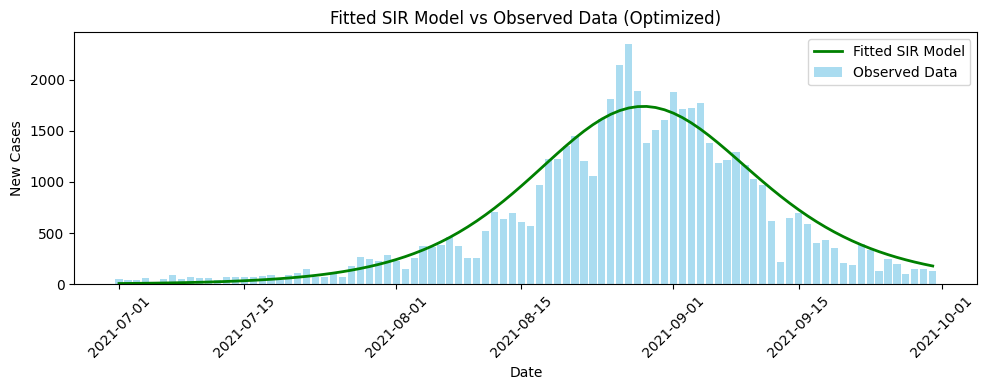

In [8]:
print("\n--- パラメータの自動推定を開始します ---")

# 最適化するための目的関数（誤差の二乗和）
def objective(params):
    beta, gamma, S_initial = params
    y_init = [S_initial, I0, R0]
    res = odeint(sir_model, y_init, t, args=(beta, gamma))
    S_sim, I_sim, R_sim = res.T
    new_cases_sim = beta * S_sim * I_sim
    # 観測値（実際の新規感染者数）との二乗誤差を計算
    error = np.sum((new_cases_sim - data_target['Aichi'].values)**2)
    return error

# 最適化の実行 (beta, gamma, S0 を探索)
initial_guess = [beta_init, gamma_init, S0_init]
# パラメータが取り得る範囲 (制約)
bounds = [(1e-8, 1e-4), (0.01, 1.0), (1000, 7500000)]

opt_result = minimize(objective, initial_guess, bounds=bounds, method='L-BFGS-B')
opt_beta, opt_gamma, opt_S0 = opt_result.x

print(f"最適化されたパラメータ:")
print(f"β (beta): {opt_beta:.8f}")
print(f"γ (gamma): {opt_gamma:.4f}")
print(f"S(0): {opt_S0:.1f}")
print(f"基本再生産数 (R0): {(opt_beta * opt_S0) / opt_gamma:.2f}")

# 最適化されたパラメータで再計算
res_opt = odeint(sir_model, [opt_S0, I0, R0], t, args=(opt_beta, opt_gamma))
new_cases_opt = opt_beta * res_opt[:, 0] * res_opt[:, 1]

# 最終結果のプロット
plt.figure(figsize=(10, 4))
plt.bar(data_target['Date'], data_target['Aichi'], color='skyblue', alpha=0.7, label='Observed Data')
plt.plot(data_target['Date'], new_cases_opt, color='green', linewidth=2, label='Fitted SIR Model')
plt.title('Fitted SIR Model vs Observed Data (Optimized)')
plt.xlabel('Date')
plt.ylabel('New Cases')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

## パラメータの値から、数理モデルの仮定を加味して、流行時の感染者数の変化を考察する。

**プロンプトの例（推定がうまくいった場合）**

> パラメータの値はxxxで、フィッティング結果が添付の画像のようになりました。この結果からわかることを考察してください。

＋画像を添付

**プロンプトの例（推定がうまくいっていない場合）**

> パラメータの値はxxxでフィッティング結果は添付の画像のようになりました。推定がうまくっていないように見えるので、修正案を提示してください。原理的に難しい場合はその理由を考察してください。

＋画像を添付

## この後は自由レポート課題を忘れずに

### 深層強化学習モデルによる感染拡大の抑制シミュレーション

#### 感染症・経済トレードオフ最適化のための深層強化学習（DRQN）アーキテクチャ

本シミュレーションは、AIエージェントが過去の時系列データ（推移）を記憶しながら、感染症の抑制と経済の維持、および市民の自粛疲れのコントロールを同時に最適化する「Deep Recurrent Q-Network (DRQN)」のアーキテクチャに基づいています。

---

##### 1. 状態空間と行動空間 (State & Action Space)

###### 状態ベクトル (State Vector)
各ステップ（1日）において、環境は以下の5次元ベクトルを観測として生成します。エージェントが学習しやすいよう、人口に関する値は総人口 $N$ で正規化されています。

$$x_t = \left[ \frac{S_t}{N}, \frac{I_t}{N}, \frac{R_t}{N}, F_t, u_{t-1} \right]$$

###### RNNのための時系列状態 (Sequence State)
エージェントは直近の状態だけでなく、過去 $K$ 日間（本実装では $K=7$）の推移を1つのシーケンスとして入力として受け取ります。

$$s_t = [x_{t-K+1}, \dots, x_{t-1}, x_t]$$
*(入力テンソルの形状: `[batch_size, 7, 5]`)*

###### 行動空間 (Action Space)
エージェント（政府）がその日に決定する「目標自粛強度」。$0.0$（制限なし）から $1.0$（完全ロックダウン）までの連続的な概念を、101段階の離散値として選択します。

$$a_t \equiv u_t \in \{0.0, 0.01, 0.02, \dots, 1.0\}$$

---

##### 2. 環境モデルのダイナミクス (Environment Dynamics)

環境はAIの決定 $u_t$ を受け取り、以下の3つの連立モデルを通じて翌日の状態を計算します。

###### A. 心理・行動モデル (Behavioral Dynamics)
市民の「自粛疲れ（Fatigue）」の蓄積と回復を定義し、要請に対する「実際の遵守率（Effective Compliance）」を算出します。

* **疲労度の更新:**
  $$F_t = \max\Big(0,\ \min\big(1,\ F_{t-1} + \alpha u_t - \kappa(1 - u_t)\big)\Big)$$
  *( $\alpha$: 蓄積係数, $\kappa$: 回復係数 )*

* **実効自粛強度:**
  $$u'_t = \max(0,\ u_t - F_t)$$

###### B. 感染動態モデル (Modified SIR Dynamics)
実効自粛強度 $u'_t$ による接触頻度の低下を2乗で効かせ、連続時間の微分方程式（Mass Action則）として1日分積分します。

* **実効感染率:**
  $$\beta'_t = \beta_0 \cdot (1 - u'_t)^2$$
  *( $\beta_0$: 最小二乗法で推定した基本感染率パラメータ )*

* **SIR微分方程式 (Nで割らないモデル):**
  $$\frac{dS}{dt} = -\beta'_t S I$$
  $$\frac{dI}{dt} = \beta'_t S I - \gamma I$$
  $$\frac{dR}{dt} = \gamma I$$

###### C. マクロ経済モデル (Macroeconomic Dynamics)
Cobb-Douglas型生産関数を応用し、隔離による労働力減少と、自粛要請による経済活動の停止を定義します。

* **実効労働力:**
  $$L_t = \frac{S_t + R_t}{N} \cdot (1 - u'_t)$$
  *( 感染者 $I_t$ は隔離され労働に参加できないと仮定 )*

* **GDP（生産量）:**
  $$Y_t = A \cdot L_t^\theta$$
  *( $A$: 全要素生産性, $\theta$: 労働分配率 )*

---

##### 3. 報酬関数 (Reward Function)

エージェントが最大化を目指す「即時報酬」。経済の維持（プラス）、感染者の増加（マイナス）、および急激な政策変更（マイナス）のトレードオフを数式化しています。

$$R_t = W_E \cdot Y_t - W_I \cdot \left(\frac{I_t}{N}\right) - W_C \cdot |u_t - u_{t-1}|$$

* $W_E$: 経済維持の重み
* $W_I$: 感染者数（医療リソース逼迫）に対するペナルティ重み
* $W_C$: 政策の急激な変更（社会的混乱）に対するペナルティ重み

---

##### 4. エージェントのアーキテクチャ (Agent Architecture)

部分観測マルコフ決定過程（POMDP）を解くため、Q関数をLSTMネットワークで近似する **DRQN (Deep Recurrent Q-Network)** を採用しています。

###### ニューラルネットワーク構造
1. **Input Layer**: `(Sequence Length: 7, State Features: 5)`
2. **Recurrent Layer**: `LSTM(Units: 32)`
   *(過去7日間の推移から隠れ状態を抽出し、勾配消失を防ぎながらトレンドを学習)*
3. **Hidden Layer**: `Dense(Units: 32, Activation: ReLU)`
4. **Output Layer**: `Dense(Units: 101, Activation: Linear)`
   *(各自粛強度の選択肢に対するQ値 $Q(s_t, a_t)$ を出力)*

###### 最適化 (Optimization)
ベルマン方程式に基づくTD誤差（Temporal Difference Error）の平均二乗誤差（MSE）を損失関数とし、Adamオプティマイザで学習します。

$$\mathcal{L}(\theta) = \mathbb{E}_{(s_t, a_t, r_t, s_{t+1}) \sim D} \left[ \left( r_t + \gamma \max_{a'} Q_{\text{target}}(s_{t+1}, a'; \theta^-) - Q(s_t, a_t; \theta) \right)^2 \right]$$

* $D$: Experience Replay バッファ
* $\gamma$: 割引率（将来の報酬をどれだけ重視するか）
* $\theta$: メインネットワークの重み / $\theta^-$: ターゲットネットワークの重み

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


学習を開始します... (LSTMによる時系列学習)
Episode: 1/150, Total Reward: -0.47, Epsilon: 0.95
Episode: 10/150, Total Reward: 11.97, Epsilon: 0.60
Episode: 20/150, Total Reward: 19.49, Epsilon: 0.36
Episode: 30/150, Total Reward: 27.67, Epsilon: 0.21
Episode: 40/150, Total Reward: 29.69, Epsilon: 0.13
Episode: 50/150, Total Reward: 41.91, Epsilon: 0.08
Episode: 60/150, Total Reward: 43.31, Epsilon: 0.05
Episode: 70/150, Total Reward: 37.03, Epsilon: 0.03
Episode: 80/150, Total Reward: 60.35, Epsilon: 0.02
Episode: 90/150, Total Reward: 52.33, Epsilon: 0.01
Episode: 100/150, Total Reward: 41.69, Epsilon: 0.01
Episode: 110/150, Total Reward: 55.85, Epsilon: 0.01
Episode: 120/150, Total Reward: 52.33, Epsilon: 0.01
Episode: 130/150, Total Reward: 52.89, Epsilon: 0.01
Episode: 140/150, Total Reward: 53.23, Epsilon: 0.01
Episode: 150/150, Total Reward: 50.58, Epsilon: 0.01


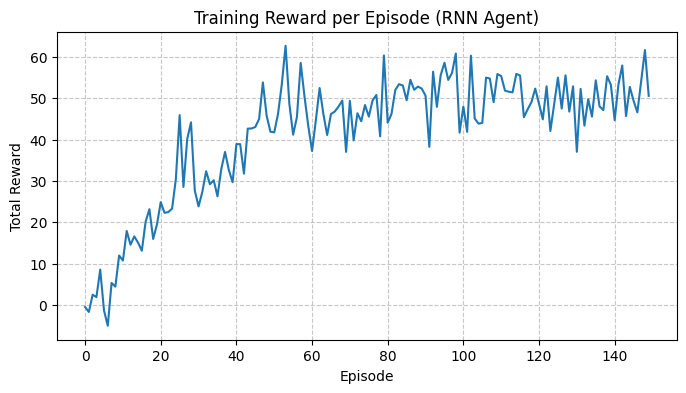

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import random
from collections import deque
import matplotlib.pyplot as plt
from scipy.integrate import odeint

# ==========================================
# 1. 環境 (Environment) の定義
# ==========================================
class EpidemicEconomyEnv:
    def __init__(self):
        # 感染動態パラメータ
        self.beta_0 = opt_beta # 基本感染率
        self.gamma = opt_gamma   # 回復率

        # 心理・行動モデルパラメータ
        self.alpha = 0.05  # 疲労の蓄積係数
        self.kappa = 0.02  # 疲労の回復係数

        # 経済モデルパラメータ
        self.A = 1.0       # 全要素生産性
        self.theta = 0.7   # 労働分配率

        # 報酬関数の重み
        self.W_E = 1.0     # 経済維持の重み
        self.W_I = 1.0     # 感染者増加のペナルティ重み
        self.W_C = 1.0

        self.max_steps = 140 # シミュレーション日数

        # アクション空間: 目標自粛強度 u_t を 0.0 から 1.0 まで 101段階から選択
        self.action_space = np.linspace(0.0, 1.0, 101)
        self.action_size = len(self.action_space)

        # 状態空間: [感受性保持者の割合, 感染者の割合, 回復者の割合, 疲労度, 前回自粛強度]
        self.state_size = 5

    def _sir_derivatives(self, y, t, beta_prime, gamma):
        S, I, R = y
        dSdt = -beta_prime * (S * I)
        dIdt = beta_prime * (S * I) - gamma * I
        dRdt = gamma * I
        return [dSdt, dIdt, dRdt]

    def reset(self):
        self.S = opt_S0 # 初期感染者
        self.I = I0
        self.R = 0.0
        self.F = 0.0 # 初期疲労度は0
        self.u_t = 0.0
        self.N = self.S + self.I  # 総人口
        self.current_step = 0
        return self._get_state()

    def _get_state(self):
        # RNN(LSTM)の学習崩壊を防ぐため、0.0〜1.0の範囲に正規化して出力
        return np.array([self.S/self.N, self.I/self.N, self.R/self.N, self.F, self.u_t], dtype=np.float32)

    def step(self, action_idx):
        prev_u_t = self.u_t
        self.u_t = self.action_space[action_idx]

        # 1. 心理・行動モデル
        self.F = max(0.0, min(1.0, self.F + self.alpha * self.u_t - self.kappa * (1.0 - self.u_t)))
        u_prime = max(0.0, self.u_t - self.F)

        # 2. 感染動態モデル
        beta_prime = self.beta_0 * (1.0 - u_prime)**2

        y0 = [self.S, self.I, self.R]
        t_span = [0, 1]
        sol = odeint(self._sir_derivatives, y0, t_span, args=(beta_prime, self.gamma))
        next_S, next_I, next_R = sol[1]

        # 新規感染者数
        new_infections = max(0.0, self.S - next_S)
        self.S, self.I, self.R = next_S, next_I, next_R

        # 3. マクロ経済モデル
        L_t = ((self.S + self.R) / self.N) * (1.0 - u_prime)
        Y_t = self.A * (L_t ** self.theta)

        # 4. 報酬の計算
        change_penalty = self.W_C * abs(self.u_t - prev_u_t)
        reward = self.W_E * Y_t - self.W_I * (self.I / self.N) - change_penalty

        self.current_step += 1
        done = self.current_step >= self.max_steps or self.I < 1.0

        return self._get_state(), reward, done, {
            'u_t': self.u_t,
            'u_prime': u_prime,
            'Y_t': Y_t,
            'new_infections': new_infections
        }

# ==========================================
# 2. DRQN (Deep Recurrent Q-Network) エージェントの定義
# ==========================================
class DQNAgent:
    def __init__(self, state_size, action_size, sequence_length=7):
        self.state_size = state_size
        self.action_size = action_size
        self.sequence_length = sequence_length # 【追加】過去何日分のデータを記憶するか
        self.memory = deque(maxlen=2000)

        # ハイパーパラメータ
        self.gamma = 0.95
        self.epsilon = 1.0
        self.epsilon_min = 0.01
        self.epsilon_decay = 0.95
        self.learning_rate = 0.001

        self.model = self._build_model()
        self.target_model = self._build_model()
        self.update_target_model()

    def _build_model(self):
        model = models.Sequential([
            # 【変更】Dense層の代わりにLSTM層を導入 (時系列データを処理)
            layers.LSTM(32, input_shape=(self.sequence_length, self.state_size)),
            layers.Dense(32, activation='relu'),
            layers.Dense(self.action_size, activation='linear')
        ])
        model.compile(loss='mse', optimizer=tf.keras.optimizers.Adam(learning_rate=self.learning_rate))
        return model

    def update_target_model(self):
        self.target_model.set_weights(self.model.get_weights())

    def remember(self, state_seq, action, reward, next_state_seq, done):
        self.memory.append((state_seq, action, reward, next_state_seq, done))

    def act(self, state_seq):
        if np.random.rand() <= self.epsilon:
            return random.randrange(self.action_size)
        act_values = self.model.predict(state_seq, verbose=0)
        return np.argmax(act_values[0])

    def replay(self, batch_size):
        if len(self.memory) < batch_size:
            return

        minibatch = random.sample(self.memory, batch_size)
        # state_seq の形状は (batch_size, sequence_length, state_size) になる
        states = np.vstack([x[0] for x in minibatch])
        actions = np.array([x[1] for x in minibatch])
        rewards = np.array([x[2] for x in minibatch])
        next_states = np.vstack([x[3] for x in minibatch])
        dones = np.array([x[4] for x in minibatch])

        target = rewards + self.gamma * np.amax(self.target_model.predict(next_states, verbose=0), axis=1) * (1 - dones)
        target_f = self.model.predict(states, verbose=0)

        for i in range(batch_size):
            target_f[i][actions[i]] = target[i]

        self.model.fit(states, target_f, epochs=1, verbose=0)

    def decay_epsilon(self):
        if self.epsilon > self.epsilon_min:
            self.epsilon *= self.epsilon_decay

# ==========================================
# 3. 学習ループ (RNN用シーケンス対応 ＆ ログ折りたたみ)
# ==========================================
if __name__ == "__main__":
    env = EpidemicEconomyEnv()

    # 過去7日間の推移を考慮するRNNエージェント
    sequence_length = 7
    agent = DQNAgent(env.state_size, env.action_size, sequence_length=sequence_length)

    episodes = 150
    batch_size = 32

    rewards_history = []

    print("学習を開始します... (LSTMによる時系列学習)")
    for e in range(episodes):
        state = env.reset()

        # 【追加】シーケンス（過去の記憶）を格納するキュー。最初は初期状態を複製して埋める
        state_history = deque([state] * sequence_length, maxlen=sequence_length)

        # LSTMに入力できる形状 (1, sequence_length, state_size) に変換
        current_state_seq = np.reshape(np.array(state_history), [1, sequence_length, env.state_size])
        total_reward = 0

        while True:
            action = agent.act(current_state_seq)
            next_state, reward, done, info = env.step(action)

            # 状態履歴を更新し、新しいシーケンスを作成
            state_history.append(next_state)
            next_state_seq = np.reshape(np.array(state_history), [1, sequence_length, env.state_size])

            agent.remember(current_state_seq, action, reward, next_state_seq, done)
            current_state_seq = next_state_seq
            total_reward += reward

            if done:
                agent.update_target_model()
                agent.decay_epsilon()

                # 【修正】エピソードの出力ログを 1, 10, 20...150 のように折りたたむ
                if e == 0 or (e + 1) % 10 == 0 or e == episodes - 1:
                    print(f"Episode: {e+1}/{episodes}, Total Reward: {total_reward:.2f}, Epsilon: {agent.epsilon:.2f}")

                rewards_history.append(total_reward)
                break

            agent.replay(batch_size)

    # 報酬関数の学習曲線のみをプロット
    plt.figure(figsize=(8, 4))
    plt.plot(rewards_history)
    plt.title('Training Reward per Episode (RNN Agent)')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

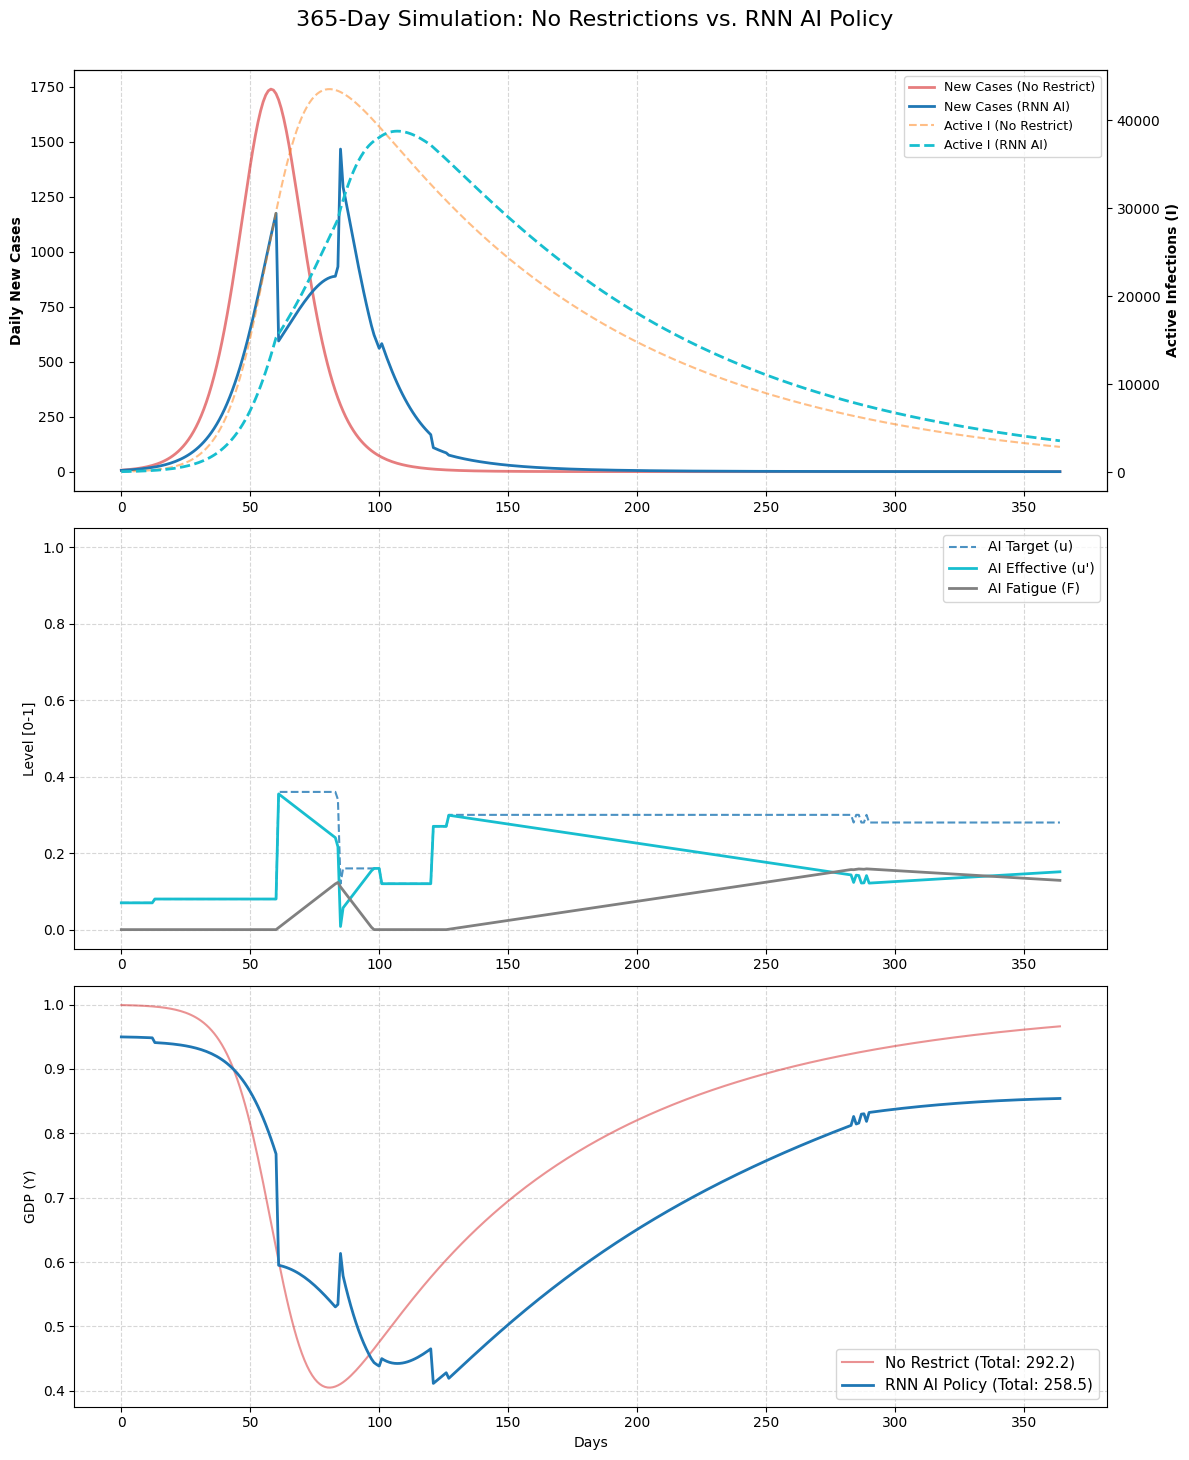

In [10]:
# ==========================================
# 365日 比較シミュレーション＆可視化セル (RNN対応・オーバーレイ版)
# ==========================================
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

# --- 0. 環境の期間を365日に延長 ---
env.max_steps = 365
sequence_length = 7  # RNNの記憶期間

# --- 1. 固定(u=0)シミュレーションの実行 ---
state_fixed = env.reset()
hist_fixed = {'new': [], 'I': [], 'u': [], 'u_prime': [], 'F': [], 'Y': []}

while True:
    # action_idx = 0 は自粛強度 u=0.0 に対応
    next_state, reward, done, info = env.step(0)
    hist_fixed['new'].append(info['new_infections'])
    hist_fixed['I'].append(env.I)
    hist_fixed['u'].append(info['u_t'])
    hist_fixed['u_prime'].append(info['u_prime'])
    hist_fixed['F'].append(env.F)
    hist_fixed['Y'].append(info['Y_t'])
    if done: break

# --- 2. 学習済みRNNエージェントによるシミュレーションの実行 ---
state_ai = env.reset()
# 過去7日分の記憶を保持するキューを作成 (初期状態を正規化して格納)
state_history = deque([state_ai] * sequence_length, maxlen=sequence_length)
hist_ai = {'new': [], 'I': [], 'u': [], 'u_prime': [], 'F': [], 'Y': []}

while True:
    # 過去7日分のリストをLSTMが受け取れる形 (1, 7, 5) に整形
    current_state_seq = np.reshape(np.array(state_history), [1, sequence_length, env.state_size])

    # 学習済みモデルによる意思決定
    action = np.argmax(agent.model.predict(current_state_seq, verbose=0)[0])
    next_state, reward, done, info = env.step(action)

    hist_ai['new'].append(info['new_infections'])
    hist_ai['I'].append(env.I)
    hist_ai['u'].append(info['u_t'])
    hist_ai['u_prime'].append(info['u_prime'])
    hist_ai['F'].append(env.F)
    hist_ai['Y'].append(info['Y_t'])

    # 状態履歴を更新
    state_history.append(next_state)
    if done: break

# --- GDPの総和を計算 ---
sum_Y_fixed = sum(hist_fixed['Y'])
sum_Y_ai = sum(hist_ai['Y'])

# ==========================================
# 3. 結合プロット (3行1列のオーバーレイ)
# ==========================================
fig, axs = plt.subplots(3, 1, figsize=(12, 15))
fig.suptitle('365-Day Simulation: No Restrictions vs. RNN AI Policy', fontsize=16, y=0.97)

# --- 1段目: 感染動態 (二軸) ---
ax1_l = axs[0]
ax1_r = ax1_l.twinx()

l1 = ax1_l.plot(hist_fixed['new'], color='tab:red', alpha=0.6, linewidth=2, label='New Cases (No Restrict)')
l2 = ax1_l.plot(hist_ai['new'], color='tab:blue', linewidth=2, label='New Cases (RNN AI)')
ax1_l.set_ylabel('Daily New Cases', fontweight='bold')

l3 = ax1_r.plot(hist_fixed['I'], color='tab:orange', linestyle='--', alpha=0.5, label='Active I (No Restrict)')
l4 = ax1_r.plot(hist_ai['I'], color='tab:cyan', linestyle='--', linewidth=2, label='Active I (RNN AI)')
ax1_r.set_ylabel('Active Infections (I)', fontweight='bold')

lines = l1 + l2 + l3 + l4
labels = [l.get_label() for l in lines]
ax1_l.legend(lines, labels, loc='upper right', fontsize=9)
ax1_l.grid(axis='x', linestyle='--', alpha=0.5)

# --- 2段目: コンプライアンスと疲労度 ---
axs[1].plot(hist_ai['u'], label='AI Target (u)', linestyle='--', color='tab:blue', alpha=0.8)
axs[1].plot(hist_ai['u_prime'], label="AI Effective (u')", color='tab:cyan', linewidth=2)
axs[1].plot(hist_ai['F'], label='AI Fatigue (F)', color='gray', linewidth=2)
axs[1].set_ylabel("Level [0-1]")
axs[1].set_ylim([-0.05, 1.05])
axs[1].legend(loc='upper right')
axs[1].grid(True, linestyle='--', alpha=0.5)

# --- 3段目: マクロ経済 (GDP総和付き) ---
axs[2].plot(hist_fixed['Y'], color='tab:red', alpha=0.5, label=f'No Restrict (Total: {sum_Y_fixed:.1f})')
axs[2].plot(hist_ai['Y'], color='tab:blue', linewidth=2, label=f'RNN AI Policy (Total: {sum_Y_ai:.1f})')
axs[2].set_ylabel("GDP (Y)")
axs[2].set_xlabel("Days")
axs[2].legend(loc='lower right', fontsize=11)
axs[2].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.subplots_adjust(top=0.93)
plt.show()

---

## 以下参考（または利用しても良い）

In [11]:
# 実行1
# ライブラリの読み込み
# 最初に1回だけ実行

import math
import matplotlib.pyplot as plt
import pandas as pd
import datetime

In [12]:
# 実行2
# データの読み込み
# 最初に1回だけ実行

data_infected = pd.read_csv("https://covid19.mhlw.go.jp/public/opendata/newly_confirmed_cases_daily.csv")

In [13]:
# 実行3
# 読み込んだデータ

data_infected

,Date,ALL,Hokkaido,Aomori,Iwate,Miyagi,Akita,Yamagata,Fukushima,Ibaraki,...,Ehime,Kochi,Fukuoka,Saga,Nagasaki,Kumamoto,Oita,Miyazaki,Kagoshima,Okinawa
0,2020/1/16,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2020/1/17,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,2020/1/18,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,2020/1/19,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2020/1/20,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1204,2023/5/4,7303,474,48,53,188,35,63,107,249,...,21,10,189,28,38,56,80,54,63,150
1205,2023/5/5,5793,354,74,61,105,36,56,74,76,...,65,18,207,19,48,70,60,23,68,172
1206,2023/5/6,6257,446,61,84,154,38,79,116,69,...,24,9,202,33,48,68,70,38,29,125
1207,2023/5/7,14344,658,127,116,293,133,117,188,106,...,105,40,687,87,114,133,121,95,168,254


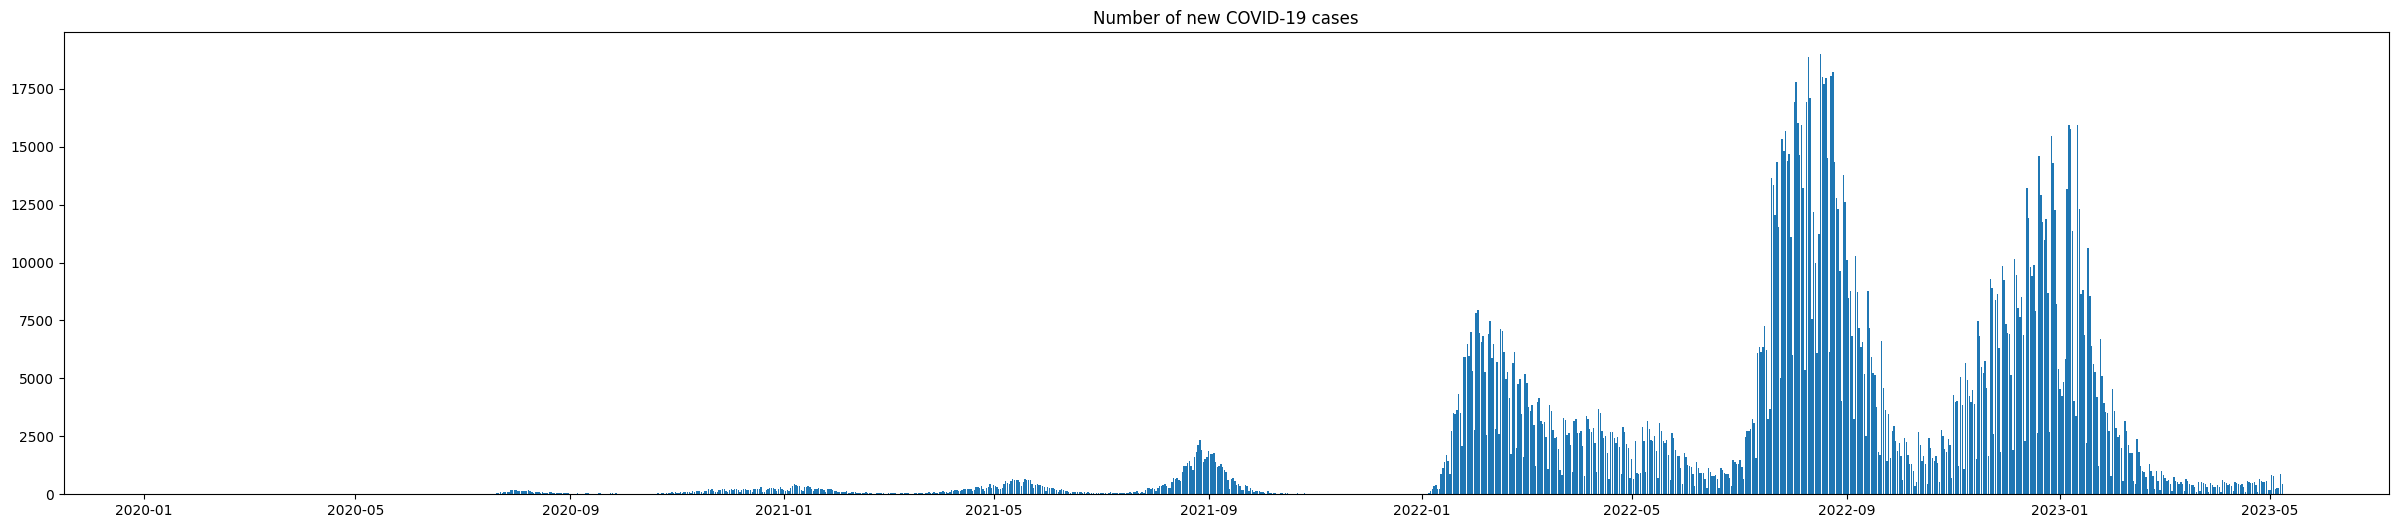

In [14]:
# 実行4
# 全データの確認

plt.figure(figsize=(30,6))
plt.bar(pd.to_datetime(data_infected['Date']), data_infected['Aichi'])
plt.title('Number of new COVID-19 cases')
plt.show()

In [15]:
# 実行5
# データの整形

data_infected['Date'] = pd.to_datetime(data_infected['Date'], format = "%Y/%m/%d")

data_infected_aichi = data_infected[['Date', 'Aichi']]
time_start1 = datetime.datetime(2021,7,1) #最初の日1
time_end1 = datetime.datetime(2021,9,30) #最後の日1
time_start2 = datetime.datetime(2022,7,1) #最初の日2
time_end2 = datetime.datetime(2022,9,30) #最後の日2
data_infected_aichi_5th = data_infected_aichi.query('@time_start1 < Date < @time_end1') # 期間1
data_infected_aichi_8th = data_infected_aichi.query('@time_start2 < Date < @time_end2') # 期間2
print(data_infected_aichi_5th)
print(data_infected_aichi_8th)

          Date  Aichi
533 2021-07-02     44
534 2021-07-03     45
535 2021-07-04     64
536 2021-07-05     21
537 2021-07-06     52
..         ...    ...
618 2021-09-25    251
619 2021-09-26    200
620 2021-09-27     99
621 2021-09-28    148
622 2021-09-29    148

[90 rows x 2 columns]
          Date  Aichi
898 2022-07-02   1470
899 2022-07-03   1164
900 2022-07-04    670
901 2022-07-05   2481
902 2022-07-06   2737
..         ...    ...
983 2022-09-25   3480
984 2022-09-26   1552
985 2022-09-27   2713
986 2022-09-28   2955
987 2022-09-29   2301

[90 rows x 2 columns]


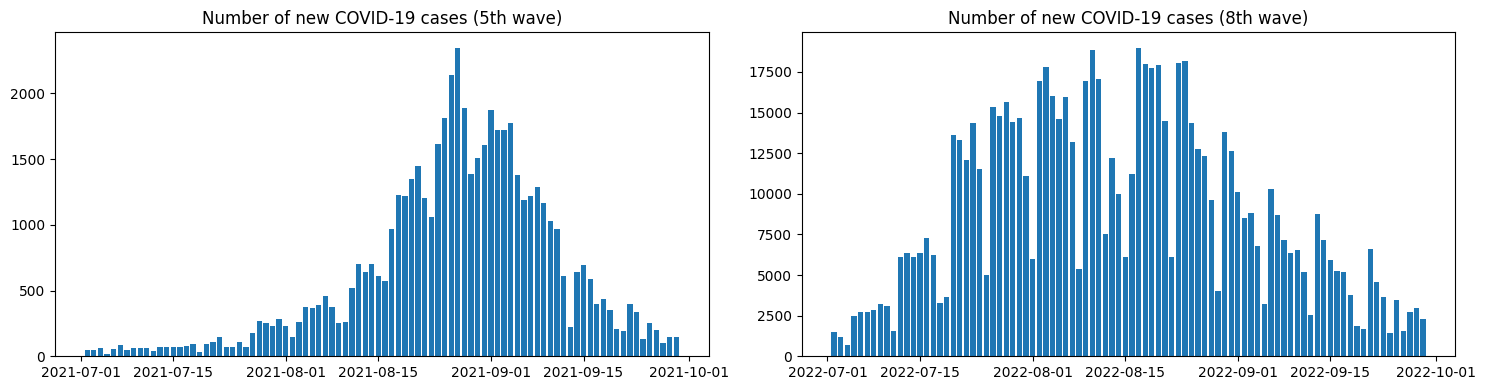

In [16]:
# 実行6
# データのプロット

fig = plt.figure(figsize = (15, 4))

ax1 = fig.add_subplot(1, 2, 1)
ax1.bar(pd.to_datetime(data_infected_aichi_5th['Date']), data_infected_aichi_5th['Aichi'])
ax1.set_title('Number of new COVID-19 cases (5th wave)')

ax2 = fig.add_subplot(1, 2, 2)
ax2.bar(pd.to_datetime(data_infected_aichi_8th['Date']), data_infected_aichi_8th['Aichi'])
ax2.set_title('Number of new COVID-19 cases (8th wave)')

fig.tight_layout()
fig.show()

In [17]:
# 実行7
# 関数の定義（変えない）

def calculate_SIR(beta = 0.000008, gamma = 0.1, x0 = 60000, y0 = 1, z0 = 0, epsilon = 0.8, epsilon_start = 1000):
  r0 = beta*x0/gamma
  print("基本再生産数は",r0,"です")

  dt = 0.01
  t = 0
  x = x0
  y = y0
  z = z0
  xList = [x]
  yList = [y]
  zList = [z]
  tList = [t]
  newinfList = [beta*x*y]
  for i in range(10000):
      t = dt*(i+1)

      if t < epsilon_start:
        xx = x + dt*(-beta*x*y)
        yy = y + dt*(beta*x*y-gamma*y)
        zz = z + dt*(gamma*y)
      else:
        xx = x + dt*(-(1 - epsilon)*beta*x*y)
        yy = y + dt*((1 - epsilon)*beta*x*y-gamma*y)
        zz = z + dt*(gamma*y)

      x = xx
      y=yy
      z=zz
      tList.append(t)
      xList.append(x)
      yList.append(y)
      zList.append(z)
      newinfList.append(beta*x*y)

  return [tList, xList, yList, zList, newinfList]

def plot_SIR(out_sir):

  # プロット

  tList = out_sir[0]
  newinfList = out_sir[4]


  fig = plt.figure(figsize = (15, 4))

  tList1 = [time_start1 + datetime.timedelta(days = i) for i in tList]
  ax1 = fig.add_subplot(1, 2, 1)

  if epsilon_start < 100:
    ax1.axvspan(time_start1 + datetime.timedelta(days = epsilon_start), time_start1 + datetime.timedelta(days = 100), color="gray", alpha=0.3)

  ax1.bar(pd.to_datetime(data_infected_aichi_5th['Date']), data_infected_aichi_5th['Aichi'])
  ax1.plot(tList1, newinfList, color="#ff0000")
  ax1.set_title('Number of new COVID-19 cases (5th wave)')

  tList2 = [time_start2 + datetime.timedelta(days = i) for i in tList]
  ax2 = fig.add_subplot(1, 2, 2)

  if epsilon_start < 100:
    ax2.axvspan(time_start2 + datetime.timedelta(days = epsilon_start), time_start2 + datetime.timedelta(days = 100), color="gray", alpha=0.3)

  ax2.bar(pd.to_datetime(data_infected_aichi_8th['Date']), data_infected_aichi_8th['Aichi'])
  ax2.plot(tList2, newinfList, color="#ff0000")
  ax2.set_title('Number of new COVID-19 cases (8th wave)')

  fig.tight_layout()
  fig.show()

def plot_SIR_all(out_sir):
  # プロット

  tList = out_sir[0]
  xList = out_sir[1]
  yList = out_sir[2]
  zList = out_sir[3]
  newinfList = out_sir[4]


  fig = plt.figure(figsize = (15, 4))

  tList1 = [time_start1 + datetime.timedelta(days = i) for i in tList]
  ax1 = fig.add_subplot(1, 2, 1)

  if epsilon_start < 100:
    ax1.axvspan(time_start1 + datetime.timedelta(days = epsilon_start), time_start1 + datetime.timedelta(days = 100), color="gray", alpha=0.3)

  ax1.bar(pd.to_datetime(data_infected_aichi_5th['Date']), data_infected_aichi_5th['Aichi'])
  ax1.plot(tList1, xList, color="#0000ff", label = 'Susceptible')
  ax1.plot(tList1, yList, color="#ffaaaa", label = 'Infectious')
  ax1.plot(tList1, zList, color="#00ff00", label = 'Recoverd')
  ax1.plot(tList1, newinfList, color="#ff0000", label = 'New cases')
  ax1.legend()
  ax1.set_title('5th wave')

  tList2 = [time_start2 + datetime.timedelta(days = i) for i in tList]
  ax2 = fig.add_subplot(1, 2, 2)

  if epsilon_start < 100:
    ax2.axvspan(time_start2 + datetime.timedelta(days = epsilon_start), time_start2 + datetime.timedelta(days = 100), color="gray", alpha=0.3)

  ax2.bar(pd.to_datetime(data_infected_aichi_8th['Date']), data_infected_aichi_8th['Aichi'])
  ax2.plot(tList2, xList, color="#0000ff", label = 'Susceptible')
  ax2.plot(tList2, yList, color="#ffaaaa", label = 'Infectious')
  ax2.plot(tList2, zList, color="#00ff00", label = 'Recoverd')
  ax2.plot(tList2, newinfList, color="#ff0000", label = 'New cases')
  ax2.legend()
  ax2.set_title('8th wave')

  fig.tight_layout()
  fig.show()

## パラメータを変更して計算してみる

ここを変えてみましょう。

基本再生産数は 4.8 です


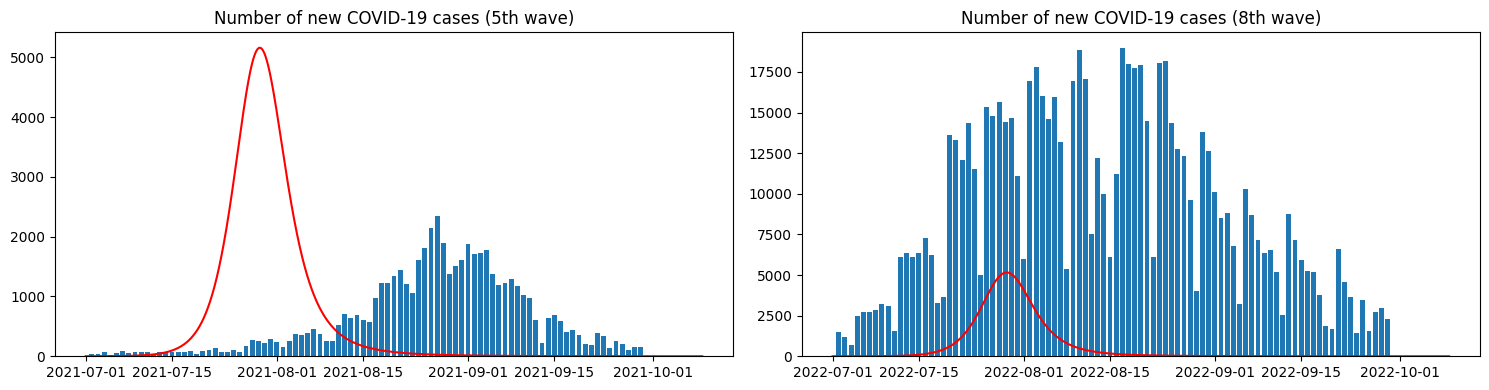

In [18]:
#メイン

# パラメータの設定（この値を提出）
beta = 0.000008 # 0.000008, 変えてみる
gamma = 0.1 # 0.1, 変えてみる
x0 = 60000 # 60000, 変えてみる
y0 = 1
z0 = 0
epsilon = 0.8 # 0.8, 0〜1, 後で変えてみる
epsilon_start = 1000 # 1000, 〜100, 後で変えてみる

# 計算とプロット（このプロットを提出）
plot_SIR(calculate_SIR(beta = beta, gamma = gamma, x0 = x0, y0 = y0, z0 = z0, epsilon = epsilon, epsilon_start = epsilon_start))

基本再生産数は 4.8 です


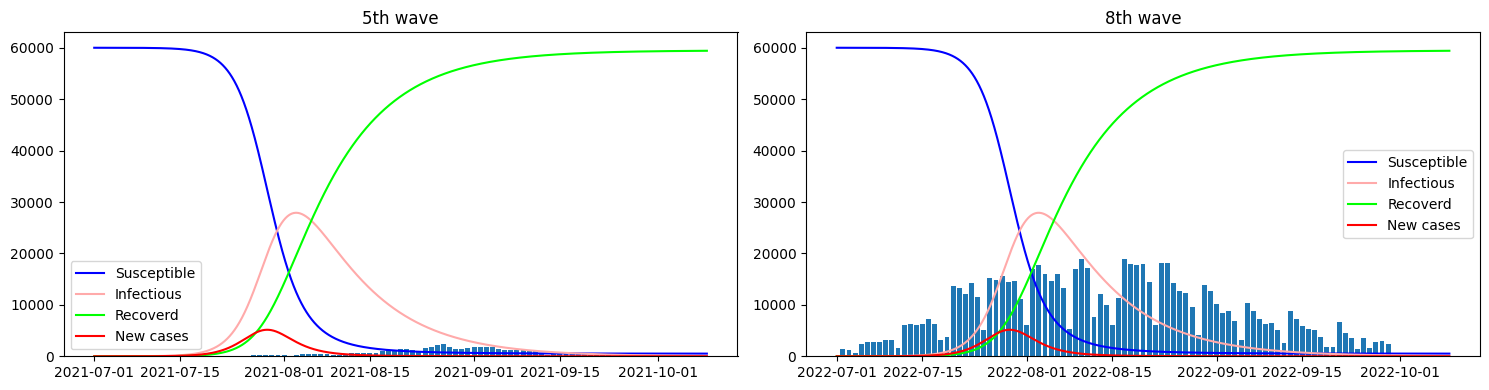

In [19]:
# 全てプロット
# 新規感染者は赤

plot_SIR_all(calculate_SIR(beta = beta, gamma = gamma, x0 = x0, y0 = y0, z0 = z0, epsilon = epsilon, epsilon_start = epsilon_start))